# Iowa Liquor Sales: ML Forecasting & Segmentation
## SARIMA, Prophet & K-Means with BigQuery

Machine learning models for sales forecasting and store segmentation using the Iowa Liquor Sales public dataset.

**Dataset**: `bigquery-public-data.iowa_liquor_sales.sales` (~33.6M rows, 2012-present)

### Contents:
1. Setup & BigQuery Connection
2. Time Series Decomposition
3. SARIMA Forecasting
4. K-Means Store Segmentation
5. Facebook Prophet Forecasting
6. Model Comparison (SARIMA vs Prophet)
7. RMSE Validation

---
## 1. Setup & BigQuery Connection

In [42]:
import pandas as pd
import numpy as np
import os
import warnings
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from google.cloud import bigquery
from google.oauth2 import service_account
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from prophet import Prophet

warnings.filterwarnings('ignore')

pd.options.display.float_format = '{:,.2f}'.format
pd.options.styler.format.formatter = '{:,}'.format

credentials = service_account.Credentials.from_service_account_file('../service_account_iowa.json')
client = bigquery.Client(credentials=credentials, project=credentials.project_id)

def run_sql(file):
    with open(f'../sql_queries/{file}') as f:
        return client.query(f.read()).to_dataframe()

def run_query(sql):
    return client.query(sql).to_dataframe()

# Currency formatter: $1K, $5M, $1.2B
def currency_fmt(x, pos):
    if abs(x) >= 1e9:
        return f'${x/1e9:.1f}B'
    elif abs(x) >= 1e6:
        return f'${x/1e6:.1f}M'
    elif abs(x) >= 1e3:
        return f'${x/1e3:.0f}K'
    else:
        return f'${x:.0f}'

currency_formatter = mticker.FuncFormatter(currency_fmt)

---
## 2. Time Series Fundamentals: The 3 Components

Every time series can be decomposed into three components:

1. **Trend**: The long-term direction (increasing, decreasing, or flat)
2. **Seasonality**: Repeating patterns at fixed intervals (weekly, monthly, yearly)
3. **Residual (Noise)**: The random variation left after removing trend and seasonality

**Decomposition types**:
- **Additive**: `Y = Trend + Seasonality + Residual` (when seasonal variation is constant)
- **Multiplicative**: `Y = Trend x Seasonality x Residual` (when seasonal variation scales with the level)


In [19]:
# Time Series Decomposition - Setup

# Pull weekly data (reused by SARIMA and Prophet sections below)
ts_decomp_df = run_query("""
    SELECT
        DATE_TRUNC(date, WEEK) AS sale_week,
        ROUND(SUM(sale_dollars), 2) AS total_sales
    FROM `bigquery-public-data.iowa_liquor_sales.sales`
    WHERE date >= '2020-01-01'
    GROUP BY sale_week
    ORDER BY sale_week
""")
ts_decomp_df['sale_week'] = pd.to_datetime(ts_decomp_df['sale_week'])
ts_decomp_df.set_index('sale_week', inplace=True)
ts_decomp = ts_decomp_df['total_sales']

# Additive decomposition (period=4 for ~monthly pattern in weekly data)
decomposition = seasonal_decompose(ts_decomp, model='additive', period=52)

print("Decomposition ready.")
print(f"  Data points: {len(ts_decomp)}")
print(f"  Date range: {ts_decomp.index[0].date()} to {ts_decomp.index[-1].date()}")

Decomposition ready.
  Data points: 322
  Date range: 2019-12-29 to 2026-02-22


In [ ]:
# 1. Original Time Series
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(ts_decomp, color='#2c3e50', linewidth=1.5)
ax.set_title('Original Time Series (Weekly Sales)', fontsize=13)
ax.set_ylabel('Sales')
ax.set_xlabel('Date')
ax.yaxis.set_major_formatter(currency_formatter)
plt.tight_layout()
plt.show()

In [ ]:
# 2. Trend - Long-term direction

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(decomposition.trend, color='#e74c3c', linewidth=2)
ax.set_title('TREND: Long-term Direction', fontsize=13)
ax.set_ylabel('Sales')
ax.set_xlabel('Date')
ax.yaxis.set_major_formatter(currency_formatter)
plt.tight_layout()
plt.show()

print(f"Trend range: ${decomposition.trend.min():,.0f} to ${decomposition.trend.max():,.0f}")

In [ ]:
# 3. Seasonality - Repeating patterns
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(decomposition.seasonal, color='#3498db', linewidth=1.5)
ax.set_title('SEASONALITY: Repeating Patterns', fontsize=13)
ax.set_ylabel('Sales')
ax.set_xlabel('Date')
ax.yaxis.set_major_formatter(currency_formatter)
plt.tight_layout()
plt.show()

print(f"Seasonal amplitude: +/- ${decomposition.seasonal.max():,.0f}")

In [ ]:
# 4. Residual (Noise) - Random variation
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(decomposition.resid, color='#95a5a6', linewidth=1, marker='o', markersize=2)
ax.axhline(y=0, color='black', linewidth=0.5, linestyle='--')
ax.set_title('RESIDUAL (Noise): Random Variation', fontsize=13)
ax.set_ylabel('Sales')
ax.set_xlabel('Date')
ax.yaxis.set_major_formatter(currency_formatter)
plt.tight_layout()
plt.show()

print(f"Residual std: ${decomposition.resid.std():,.0f} (lower = better model fit)")

In [ ]:
# Complete Decomposition - All 4 components together
fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)

axes[0].plot(ts_decomp, color='#2c3e50', linewidth=1.5)
axes[0].set_title('Original Time Series (Weekly Sales)', fontsize=12)
axes[0].set_ylabel('Sales')
axes[0].yaxis.set_major_formatter(currency_formatter)

axes[1].plot(decomposition.trend, color='#e74c3c', linewidth=2)
axes[1].set_title('TREND', fontsize=12)
axes[1].set_ylabel('Sales')
axes[1].yaxis.set_major_formatter(currency_formatter)

axes[2].plot(decomposition.seasonal, color='#3498db', linewidth=1.5)
axes[2].set_title('SEASONALITY', fontsize=12)
axes[2].set_ylabel('Sales')
axes[2].yaxis.set_major_formatter(currency_formatter)

axes[3].plot(decomposition.resid, color='#95a5a6', linewidth=1, marker='o', markersize=2)
axes[3].axhline(y=0, color='black', linewidth=0.5, linestyle='--')
axes[3].set_title('RESIDUAL (Noise)', fontsize=12)
axes[3].set_ylabel('Sales')
axes[3].set_xlabel('Date')
axes[3].yaxis.set_major_formatter(currency_formatter)

plt.suptitle('Time Series Decomposition: Y = Trend + Seasonality + Residual', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## 3. SARIMA Forecasting

**SARIMA** = **S**easonal **A**uto**R**egressive **I**ntegrated **M**oving **A**verage

| Component | What it does |
|-----------|-------------|
| **AR** (AutoRegressive) | Uses past values to predict the next (e.g., last week's sales help predict this week) |
| **I** (Integrated) | Differences the data to remove trend and make it stationary |
| **MA** (Moving Average) | Uses past forecast errors to correct predictions |
| **S** (Seasonal) | Adds a second layer of AR + I + MA for repeating seasonal patterns |

**Parameters**:
- `(p, d, q)` = non-seasonal: AR order, differencing, MA order
- `(P, D, Q, m)` = seasonal: same logic but for the seasonal cycle, where `m` = period (52 weeks = yearly)

**Model Selection**: We test 4 parameter combinations and compare AIC (lower = better balance of accuracy vs complexity):
1. `(1,1,1)(1,1,0,52)` - baseline
2. `(2,1,1)(1,1,0,52)` - more AR terms
3. `(1,1,2)(1,1,0,52)` - more MA terms
4. `(1,1,1)(2,1,0,52)` - deeper seasonal AR (looks 2 years back)


In [28]:
# Pull weekly aggregated sales from BigQuery
weekly_sales_df = run_query("""
    SELECT
        DATE_TRUNC(date, WEEK) AS sale_week,
        ROUND(SUM(sale_dollars), 2) AS total_sales
    FROM `bigquery-public-data.iowa_liquor_sales.sales`
    WHERE date >= '2020-01-01'
    GROUP BY sale_week
    ORDER BY sale_week
""")
weekly_sales_df['sale_week'] = pd.to_datetime(weekly_sales_df['sale_week'])
weekly_sales_df.set_index('sale_week', inplace=True)
weekly_sales_df.head()

,total_sales
sale_week,
2019-12-29,"2,959,875.47"
2020-01-05,"5,496,356.17"
2020-01-12,"5,022,218.36"
2020-01-19,"5,717,027.13"
2020-01-26,"5,599,021.13"


In [40]:
# Fit SARIMA model
ts = weekly_sales_df['total_sales']

model_1 = SARIMAX(
    ts,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 0, 52),  # weekly seasonality
    enforce_stationarity=False,
    enforce_invertibility=False
)
results_1 = model_1.fit(disp=False)
print(results_1.summary().tables[0])

model_2 = SARIMAX(
    ts,
    order=(2, 1, 1),
    seasonal_order=(1, 1, 0, 52),  # weekly seasonality
    enforce_stationarity=False,
    enforce_invertibility=False
)
results_2 = model_2.fit(disp=False)
print(results_2.summary().tables[0])

model_3 = SARIMAX(
    ts,
    order=(1, 1, 2),
    seasonal_order=(1, 1, 0, 52),  # weekly seasonality
    enforce_stationarity=False,
    enforce_invertibility=False
)
results_3 = model_3.fit(disp=False)
print(results_3.summary().tables[0])

model = SARIMAX(
    ts,
    order=(1, 1, 1),
    seasonal_order=(2, 1, 0, 52),  # weekly seasonality
    enforce_stationarity=False,
    enforce_invertibility=False
)
results = model.fit(disp=False)
print(results.summary().tables[0])


                                      SARIMAX Results                                      
Dep. Variable:                         total_sales   No. Observations:                  322
Model:             SARIMAX(1, 1, 1)x(1, 1, [], 52)   Log Likelihood               -3266.558
Date:                             Sun, 29 Mar 2026   AIC                           6541.116
Time:                                     16:00:11   BIC                           6554.617
Sample:                                 12-29-2019   HQIC                          6546.570
                                      - 02-22-2026                                         
Covariance Type:                               opg                                         
                                      SARIMAX Results                                      
Dep. Variable:                         total_sales   No. Observations:                  322
Model:             SARIMAX(2, 1, 1)x(1, 1, [], 52)   Log Likelihood             

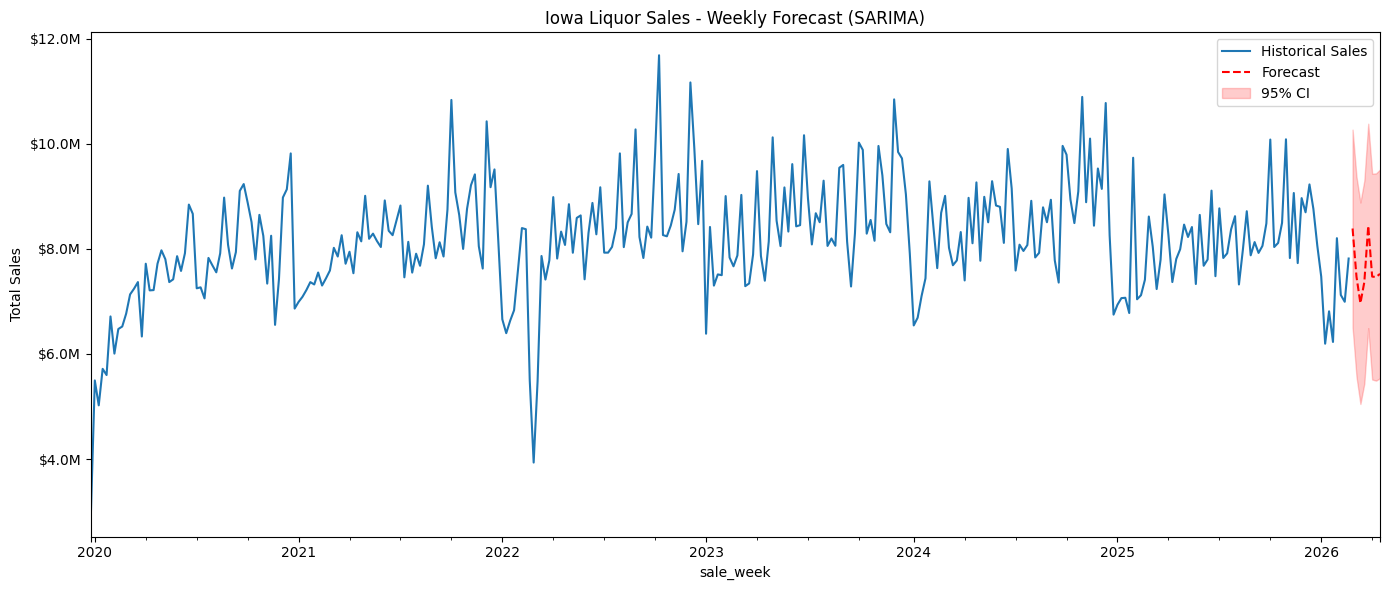


Forecast Summary:


,Forecast,Lower CI,Upper CI
2026-03-01,"8,388,879.48","6,506,363.16","10,271,395.81"
2026-03-08,"7,470,753.81","5,567,077.25","9,374,430.36"
2026-03-15,"6,965,746.54","5,047,825.17","8,883,667.91"
2026-03-22,"7,369,072.48","5,437,197.42","9,300,947.54"
2026-03-29,"8,438,446.59","6,492,723.63","10,384,169.55"
2026-04-05,"7,473,686.86","5,514,214.04","9,433,159.68"
2026-04-12,"7,465,041.54","5,491,914.69","9,438,168.40"
2026-04-19,"7,525,666.18","5,538,979.12","9,512,353.23"


In [43]:
# Forecast next 8 weeks
forecast_steps = 8
forecast = results.get_forecast(steps=forecast_steps)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

# Plot
fig, ax = plt.subplots(figsize=(14, 6))
ts.plot(ax=ax, label='Historical Sales')
forecast_mean.plot(ax=ax, label='Forecast', color='red', linestyle='--')
ax.fill_between(
    forecast_ci.index,
    forecast_ci.iloc[:, 0],
    forecast_ci.iloc[:, 1],
    alpha=0.2, color='red', label='95% CI'
)
ax.set_title('Iowa Liquor Sales - Weekly Forecast (SARIMA)')
ax.set_ylabel('Total Sales')
ax.yaxis.set_major_formatter(currency_formatter)
ax.legend()
plt.tight_layout()
plt.show()

print('\nForecast Summary:')
forecast_summary = pd.DataFrame({
    'Forecast': forecast_mean.round(2),
    'Lower CI': forecast_ci.iloc[:, 0].round(2),
    'Upper CI': forecast_ci.iloc[:, 1].round(2)
})
forecast_summary

---
## 4. K-Means Store Segmentation

- K-Means groups similar stores based on sales behavior
- Log-transform handles skewed retail data
- Business value: different strategies for High/Mid/Low volume stores

In [58]:
# Pull store-level aggregations from BigQuery
store_df = run_query("""
    SELECT
        store_number,
        store_name,
        city,
        ROUND(SUM(sale_dollars), 2) AS total_sales,
        SUM(bottles_sold) AS total_bottles,
        COUNT(*) AS num_transactions,
        ROUND(AVG(sale_dollars), 2) AS avg_transaction
    FROM `bigquery-public-data.iowa_liquor_sales.sales`
    WHERE date >= '2020-07-01'
    GROUP BY store_number, store_name, city
    HAVING COUNT(*) >= 10
""")
print(f'Stores to segment: {len(store_df)}')
store_df.head()

Stores to segment: 2974


,store_number,store_name,city,total_sales,total_bottles,num_transactions,avg_transaction
0,4275,FAREWAY STORES #980 / KNOXVILLE,KNOXVILLE,"1,480,779.43",84091,6257,236.66
1,2538,HY-VEE FOOD STORE #3 (1866) / WATERLOO,WATERLOO,"4,001,460.38",231648,32682,122.44
2,2527,HY-VEE FOOD STORE #5 (1151) / DES MOINES,DES MOINES,"4,058,574.10",313052,18925,214.46
3,5197,KUM & GO #201 / CORALVILLE,CORALVILLE,"475,780.02",41785,9388,50.68
4,5480,CASEY'S GENERAL STORE #3385 / ORANGE CITY,ORANGE CITY,"292,418.54",30071,2237,130.72


In [59]:
# Prepare features for clustering
features = ['total_sales', 'total_bottles', 'num_transactions']
X = store_df[features].copy()
X_log = np.log1p(X)  # Log transform to handle skewness

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

# K-Means with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
store_df['cluster'] = kmeans.fit_predict(X_scaled)

# Label clusters by sales volume
cluster_means = store_df.groupby('cluster')['total_sales'].mean().sort_values(ascending=False)
label_map = {cluster_means.index[0]: 'High-Hub', cluster_means.index[1]: 'Mid-Hub', cluster_means.index[2]: 'Low-Hub'}
store_df['segment'] = store_df['cluster'].map(label_map)

# Summary
print('\nSegment Summary:')
store_df.groupby('segment').agg({
    'store_number': 'count',
    'total_sales': ['mean', 'sum'],
    'total_bottles': 'mean',
    'num_transactions': 'mean'
}).round(2)


Segment Summary:


store_number  total_sales                  total_bottles  \
                count         mean              sum          mean   
segment                                                             
High-Hub          939 2,229,436.03 2,093,440,433.55    150,319.31   
Low-Hub           585    24,766.57    14,488,441.09      2,114.16   
Mid-Hub          1450   234,853.80   340,538,006.97     22,369.86   

         num_transactions  
                     mean  
segment                    
High-Hub        12,119.43  
Low-Hub            225.12  
Mid-Hub          2,134.35

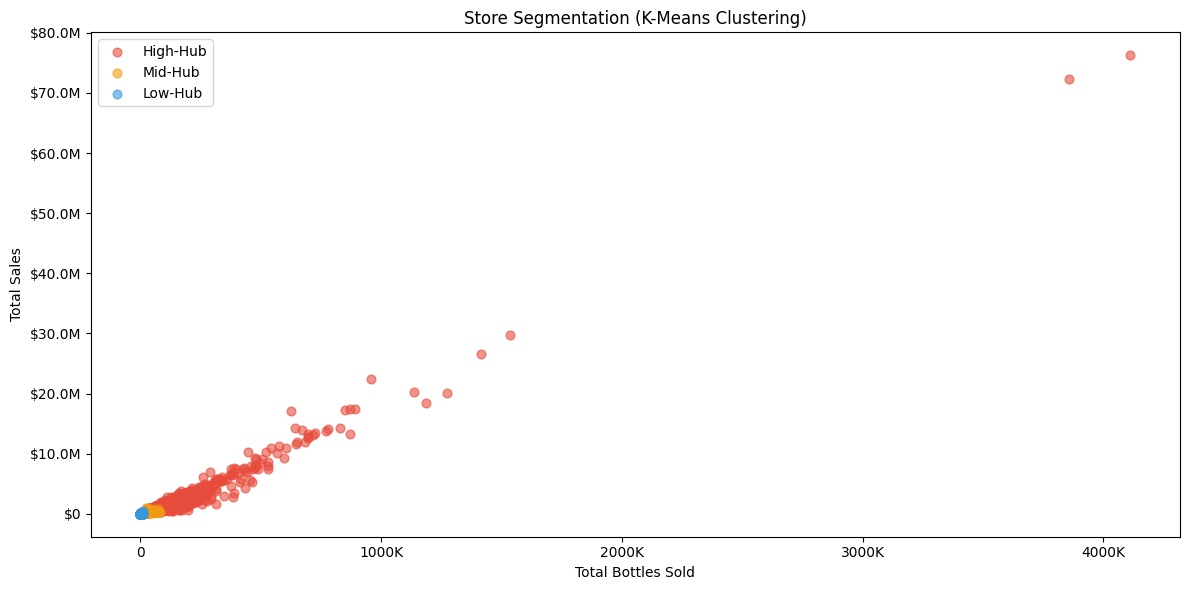

In [60]:
# Visualization
fig, ax = plt.subplots(figsize=(12, 6))
colors = {'High-Hub': '#e74c3c', 'Mid-Hub': '#f39c12', 'Low-Hub': '#3498db'}

for segment, color in colors.items():
    mask = store_df['segment'] == segment
    ax.scatter(
        store_df.loc[mask, 'total_bottles'],
        store_df.loc[mask, 'total_sales'],
        c=color, label=segment, alpha=0.6, s=40
    )

ax.set_xlabel('Total Bottles Sold')
ax.set_ylabel('Total Sales')
ax.set_title('Store Segmentation (K-Means Clustering)')
ax.yaxis.set_major_formatter(currency_formatter)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x/1e3:.0f}K' if x >= 1e3 else f'{x:.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

---
## 5. Facebook Prophet - Forecasting

Prophet is Meta's open-source forecasting library. Great for business time series because:
- Handles **holidays** and **seasonality** automatically
- Robust to **missing data** and **outliers**
- Intuitive parameters (no need to tune p,d,q like SARIMA)



In [ ]:
# Prophet requires columns named 'ds' (date) and 'y' (value)
prophet_df = weekly_sales_df.reset_index()[['sale_week', 'total_sales']].copy()
prophet_df.columns = ['ds', 'y']
prophet_df['ds'] = pd.to_datetime(prophet_df['ds'])

# Fit Prophet model
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,  # our data is already weekly aggregated
    daily_seasonality=False,
    changepoint_prior_scale=0.05  # controls flexibility (lower = less overfitting)
)
prophet_model.fit(prophet_df)

# Forecast 8 weeks ahead
future = prophet_model.make_future_dataframe(periods=forecast_steps, freq='W')
prophet_forecast = prophet_model.predict(future)

# Plot Prophet's built-in visualization
fig1 = prophet_model.plot(prophet_forecast, figsize=(14, 6))
plt.title('Prophet Forecast - Iowa Liquor Sales')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.show()

# Show components (trend + seasonality)
fig2 = prophet_model.plot_components(prophet_forecast, figsize=(14, 8))
plt.tight_layout()
plt.show()

print('\nProphet Forecast (next 8 weeks):')
prophet_forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(forecast_steps)

---
## 6. Model Comparison - SARIMA vs Prophet

Comparing both models side-by-side on the same chart to see which forecast looks more reasonable.



In [ ]:
# Side-by-side comparison: SARIMA vs Prophet on the same chart
fig, ax = plt.subplots(figsize=(16, 7))

# Historical data (last 12 weeks for cleaner view)
ts_recent = ts.tail(12)
ax.plot(ts_recent.index, ts_recent.values, 'ko-', label='Historical Sales', markersize=5)

# SARIMA forecast
ax.plot(forecast_mean.index, forecast_mean.values, 'rs--', label='SARIMA Forecast', markersize=6)
ax.fill_between(
    forecast_ci.index,
    forecast_ci.iloc[:, 0],
    forecast_ci.iloc[:, 1],
    alpha=0.15, color='red', label='SARIMA 95% CI'
)

# Prophet forecast (last 8 rows = forecast period)
prophet_future = prophet_forecast.tail(forecast_steps)
ax.plot(
    pd.to_datetime(prophet_future['ds']),
    prophet_future['yhat'],
    'b^--', label='Prophet Forecast', markersize=6
)
ax.fill_between(
    pd.to_datetime(prophet_future['ds']),
    prophet_future['yhat_lower'],
    prophet_future['yhat_upper'],
    alpha=0.15, color='blue', label='Prophet 95% CI'
)

ax.set_title('Model Comparison: SARIMA vs Prophet (8-Week Forecast)', fontsize=14)
ax.set_ylabel('Total Sales')
ax.set_xlabel('Week')
ax.yaxis.set_major_formatter(currency_formatter)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Numerical comparison table
comparison = pd.DataFrame({
    'Week': range(1, forecast_steps + 1),
    'SARIMA': forecast_mean.values.round(2),
    'SARIMA_Lower': forecast_ci.iloc[:, 0].values.round(2),
    'SARIMA_Upper': forecast_ci.iloc[:, 1].values.round(2),
    'Prophet': prophet_future['yhat'].values.round(2),
    'Prophet_Lower': prophet_future['yhat_lower'].values.round(2),
    'Prophet_Upper': prophet_future['yhat_upper'].values.round(2),
})
comparison['Difference'] = (comparison['SARIMA'] - comparison['Prophet']).round(2)
comparison['Diff_Pct'] = ((comparison['SARIMA'] - comparison['Prophet']) / comparison['Prophet'] * 100).round(2)

print('\nForecast Comparison Table:')
comparison

### 7. RMSE: Root Mean Squared Error (Model Validation)

**RMSE** measures how far off your predictions are from reality. Lower = better.

**Formula**: $RMSE = \sqrt{\frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2}$

**Steps** (same logic as Standard Deviation, but applied to prediction errors):
1. Calculate **errors**: actual - predicted
2. **Square** each error
3. Take the **mean** of squared errors (= MSE)
4. Take the **square root** (= RMSE)

RMSE is in the same units as your data ($), making it easy to interpret.


In [ ]:
# RMSE Validation - Train/Test Split approach

# Split data: use last 8 weeks as test set, rest as training
test_size = 8
ts_train = ts[:-test_size]
ts_test = ts[-test_size:]

print(f"Training set: {len(ts_train)} weeks")
print(f"Test set: {len(ts_test)} weeks")
print(f"Test period: {ts_test.index[0].date()} to {ts_test.index[-1].date()}\n")

# --- SARIMA on training data ---
sarima_train = SARIMAX(
    ts_train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 0, 52),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)
sarima_pred = sarima_train.get_forecast(steps=test_size).predicted_mean

# --- Prophet on training data ---
prophet_train_df = ts_train.reset_index()
prophet_train_df.columns = ['ds', 'y']
prophet_train_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.05
)
prophet_train_model.fit(prophet_train_df)
future_test = prophet_train_model.make_future_dataframe(periods=test_size, freq='W')
prophet_pred = prophet_train_model.predict(future_test).tail(test_size)

# --- Manual RMSE calculation (step by step) ---
actual = ts_test.values
sarima_predicted = sarima_pred.values
prophet_predicted = prophet_pred['yhat'].values

print("=== RMSE Manual Calculation (SARIMA) ===")
errors_sarima = actual - sarima_predicted
squared_errors = errors_sarima ** 2
mse = squared_errors.mean()
rmse_manual = np.sqrt(mse)

for i in range(len(actual)):
    print(f"  Week {i+1}: actual=${actual[i]:>12,.2f}  predicted=${sarima_predicted[i]:>12,.2f}  error=${errors_sarima[i]:>12,.2f}  error²=${squared_errors[i]:>16,.2f}")
print(f"\n  MSE  = {mse:,.2f}")
print(f"  RMSE = sqrt({mse:,.2f}) = ${rmse_manual:,.2f}")

# --- Compare both models ---
sarima_rmse = np.sqrt(mean_squared_error(actual, sarima_predicted))
prophet_rmse = np.sqrt(mean_squared_error(actual, prophet_predicted))
sarima_mae = mean_absolute_error(actual, sarima_predicted)
prophet_mae = mean_absolute_error(actual, prophet_predicted)

print(f"\n{'='*50}")
print(f"MODEL VALIDATION RESULTS ({test_size}-week holdout)")
print(f"{'='*50}")
print(f"{'Metric':<15} {'SARIMA':>15} {'Prophet':>15} {'Winner':>10}")
print(f"{'-'*55}")
print(f"{'RMSE':<15} ${sarima_rmse:>13,.2f} ${prophet_rmse:>13,.2f} {'SARIMA' if sarima_rmse < prophet_rmse else 'Prophet':>10}")
print(f"{'MAE':<15} ${sarima_mae:>13,.2f} ${prophet_mae:>13,.2f} {'SARIMA' if sarima_mae < prophet_mae else 'Prophet':>10}")
print(f"{'='*55}")

# Visualization: actual vs predicted
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(ts_test.index, actual, 'ko-', label='Actual Sales', markersize=8, linewidth=2)
ax.plot(ts_test.index, sarima_predicted, 'rs--', label=f'SARIMA (RMSE: ${sarima_rmse:,.0f})', markersize=7)
ax.plot(ts_test.index, prophet_predicted, 'b^--', label=f'Prophet (RMSE: ${prophet_rmse:,.0f})', markersize=7)
ax.set_title(f'Model Validation: Actual vs Predicted ({test_size}-Week Holdout)', fontsize=14)
ax.set_ylabel('Total Sales')
ax.set_xlabel('Week')
ax.yaxis.set_major_formatter(currency_formatter)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()